# Lab: Data exploration

---

<a id="learning-objectives"></a>
## Learning Objectives
*After completing this lab, you will be able to:*

- Explore and interrogate different data sets using our pandas and matplotlib.
- Interpret the findings to understand what the data tells us about the real world.

<a id="coffee"></a>

# <font color='blue'> Coffee shop data</font>

## Part A

In this Lab we'll be working with one datasets.
    
The dataset consists of coffee shop transactions, a dataset created by IBM and made available on [Kaggle](https://www.kaggle.com/datasets/ylchang/coffee-shop-sample-data-1113).

The data consists of coffee shop transactions in April 2019.

There are ~50,000 total transactions in the data set. The data consists of transactions from shops in New York City only.

Our task is to answer 3 questions:
1. **Which products offer the best margins?**
2. **Are particular customer groups spending more?**
3. **Which products generate the most sales?**

<br />

Let's start by reading in the data as a pandas `DataFrame` called `coffee_df`.

In [130]:
# Importing needed library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### 1.❓ Next, let's read in the data as a pandas `DataFrame` called `coffee_df`

In [131]:
coffee_df = pd.read_csv('./data/coffee_shop_lab.csv')

##### 2.❓Now preview the first 5 rows of the data.

In [132]:
coffee_df.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials


##### 3.❓ How many rows and columns does the dataset have?

In [133]:
coffee_df.shape

(49894, 13)

##### 4.❓ Check the type of data in each column- do you notice any problems?

In [134]:
coffee_df.dtypes

transaction_date               str
transaction_time               str
customer_id                float64
quantity                     int64
line_item_amount           float64
unit_price                 float64
product_group                  str
product_category               str
product_type                   str
current_wholesale_price    float64
customer_since                 str
customer_birth_year        float64
customer_generation            str
dtype: object

> 👉 **Write Your Findings Here**: transaction date and time also customer since as str and customer id as float instead of int
-- -

##### 5.❓ You might have noticed earlier when running the `dtypes` command that the `transaction_date` and `customer_since` columns are currently being treated like strings. We need to convert them into date columns so we can calculate factors like how long someone's been a customer.

Try using pd.to_datetime() to convert these two columns to date representations

In [135]:
coffee_df['transaction_date'] = pd.to_datetime(coffee_df['transaction_date'])
coffee_df['customer_since'] = pd.to_datetime(coffee_df['customer_since'])

##### 6.❓ Examine the percentage of missing values in each column. What might these missing values represent? How would you suggest handling them?



In [136]:
coffee_df.isnull().mean() * 100

transaction_date            0.000000
transaction_time            0.000000
customer_id                50.172365
quantity                    0.000000
line_item_amount            0.000000
unit_price                  0.000000
product_group               0.000000
product_category            0.000000
product_type                0.000000
current_wholesale_price     0.000000
customer_since             50.190404
customer_birth_year        50.190404
customer_generation        50.190404
dtype: float64

👉 Since more than 50% of the customer-related data is missing

👉 The missing values in the customer-related columns of your coffee dataset could represent:

- Guest Customers 
- Incomplete Data Collection 
- Data Integration Issues
  

👉 Is the missing values essentials to your analysis? 
- If necessary:
    - consider finding the missing values
    - Or, create a dataset that contains the rows that have filled information and discard the rows that have null values for that customer-related columns.

- If not necessary in your analysis, just ignore them

##### 7.❓ Check for duplicate values, and remove them if any.

In [137]:
coffee_df.duplicated().sum()

np.int64(149)

In [138]:
coffee_df = coffee_df.drop_duplicates()
coffee_df.duplicated().sum()

np.int64(0)

##### 8.❓ Explore the unique values in all the categorical columns:
- product group
- product category
- product type
- customer_generation

1. What inconsistencies do you notice?
2. Is there a spelling consistency?
3. Do you need to fix anything?

In [139]:
coffee_df['product_group'].unique()

<ArrowStringArray>
['Beverages', 'Food', 'Whole Bean/Teas', 'Add-ons', 'Merchandise']
Length: 5, dtype: str

In [140]:
coffee_df['product_category'].unique()

<ArrowStringArray>
[               'Tea',             'Coffee', 'Drinking Chocolate',
             'Bakery',       'Coffee beans',           'Flavours',
          'Loose Tea', 'Packaged Chocolate',            'Branded']
Length: 9, dtype: str

In [141]:
coffee_df['product_type'].unique()

<ArrowStringArray>
[      'Brewed Chai tea', 'Organic brewed coffee',      'Brewed Green tea',
           'Drip coffee', 'Premium brewed coffee', 'Gourmet brewed coffee',
      'Brewed Black tea',         'Hot chocolate',      'Barista Espresso',
                 'Scone',     'Brewed herbal tea',              'Biscotti',
                'Pastry',         'Organic Beans',         'Regular syrup',
            'Herbal tea',         'Gourmet Beans',             'Black tea',
      'Sugar free syrup',     'House blend Beans',         'Premium Beans',
              'Chai tea',     'Organic Chocolate',    'Drinking Chocolate',
           'Green beans',             'Green tea',        'Espresso Beans',
            'Housewares',              'Clothing']
Length: 29, dtype: str

In [142]:
coffee_df['customer_generation'].unique()

<ArrowStringArray>
[  'Older Millennials',        'Baby Boomers',               'Gen Z',
               'Gen X', 'Younger Millennials',                   nan]
Length: 6, dtype: str

##### 9.❓The `describe()` method is a handy way of accessing summary statistics for an entire `DataFrame` in one go. Try running it on your `DataFrame`:


In [143]:
coffee_df.describe()

,transaction_date,customer_id,quantity,line_item_amount,unit_price,current_wholesale_price,customer_since,customer_birth_year
count,49745,24801.000000,49745.000000,49745.000000,49745.000000,49745.000000,24792,24792.000000
mean,2019-04-15 01:25:20.257312,4582.647837,1.439481,4.687731,3.384018,1.354957,2018-02-21 06:10:48.209099,1978.248871
min,2019-04-01 00:00:00,1.000000,1.000000,0.000000,0.800000,0.040000,2017-01-03 00:00:00,1950.000000
25%,2019-04-08 00:00:00,584.000000,1.000000,3.000000,2.500000,0.600000,2017-08-05 00:00:00,1965.000000
50%,2019-04-15 00:00:00,5417.000000,1.000000,3.750000,3.000000,0.750000,2018-02-22 00:00:00,1981.000000
75%,2019-04-22 00:00:00,8099.000000,2.000000,6.000000,3.750000,1.950000,2018-09-16 00:00:00,1992.000000
max,2019-04-29 00:00:00,8501.000000,8.000000,360.000000,45.000000,36.000000,2019-04-09 00:00:00,2001.000000
std,NaN,3247.554091,0.543316,4.441833,2.686402,2.204466,NaN,15.088333


##### 10.❓What is your findings about the above summery statistics? 

>Write your findings here:"The dataset captures ~50k transactions from April 2019, though roughly half of these records are missing customer-specific data such as customer ID and birth year. While typical purchases are small (average quantity of 1.44 and median spend of 3.75)significant outliers exist, highlighted by a maximum line item amount of 360.00 compared to the 75th percentile of just 6.00."

👉 The `line_item_amount` column has a minimum value of 0, which seems unusual. This could indicate potential error values.

👉 The quantity column appears to be right-skewed, with 75% of orders containing only two products, while the maximum quantity is 8.

- Let's start to clean up our dataset and answer the questions in our analysis.

- We have the total line item amount (the retail price) as well as the wholesale price of the product.

- We want to calculate the **total wholesale line item amount** so we can use it to calculate profit.

##### 11.❓Can you combine the existing wholesale amount and quantity columns to create a new column in the `DataFrame` called `total_wholesale_amount` which holds the new values?

In [144]:
coffee_df['total_wholesale_amount'] = coffee_df['quantity'] * coffee_df['current_wholesale_price']

##### 12.❓Can you now create a new column called `profit` which shows the difference between the wholesale price and retail price(line_item_amount)?

In [145]:
coffee_df['profit'] = coffee_df['line_item_amount'] - coffee_df['total_wholesale_amount']

##### 13.❓Find the highest sale price in the dataset.

In [146]:
coffee_df['line_item_amount'].max()

np.float64(360.0)

##### 14.❓Find the largest amount of profit.

In [147]:
coffee_df['profit'].max()

np.float64(72.0)

The largest profit is significant - but it's obviously not representative of how much profit is made on each transaction on average.

##### 15.❓Find the mean of all the profit.

In [148]:
coffee_df['profit'].mean()

np.float64(2.9367379636144335)

##### 16.❓Now, let's start filtering our data by writing logical tests. How many transactions were valued above the **mean** transaction amount?

In [149]:
(coffee_df['line_item_amount'] > coffee_df['line_item_amount'].mean()).sum()

np.int64(19544)

##### 17.❓Create a new column called `profit_ratio` which shows the ratio between the wholesale and retail prices.

In [150]:
coffee_df['profit_ratio'] = coffee_df['line_item_amount'] / coffee_df['total_wholesale_amount']

##### 18.❓Based on profit ratio, How many transactions made a profit of at least 2 times their wholesale cost?

In [151]:
(coffee_df['profit_ratio'] >= 2).sum()

np.int64(37260)

##### 19.❓How many transactions in the dataset were for coffee `beans`? You'll have to think creatively about where this information is stored in the dataset, and how to extract it.

In [152]:
coffee_df[coffee_df['product_type'].str.lower().str.contains('beans')].shape[0]

587

##### 20.❓Sort the dataset in descending order of profit, to find the transaction that generated the highest profit.

In [153]:
coffee_df.sort_values('profit', ascending=False).head(1)

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio
49088,2019-04-17,11:18:31,NaN,8,360.0,45.0,Whole Bean/Teas,Coffee beans,Premium Beans,36.0,NaT,NaN,NaN,288.0,72.0,1.25


##### 21.❓Did any transactions make a loss where the profit is less than 0?


In [154]:
coffee_df[coffee_df['profit'] < 0]

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio
37654,2019-04-07,07:00:50,5211.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2018-07-01,1994.0,Younger Millennials,2.44,-1.44,0.409836
37656,2019-04-07,08:06:36,5531.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2017-02-23,1953.0,Baby Boomers,2.44,-1.44,0.409836
37658,2019-04-07,08:39:48,5736.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2017-01-04,1980.0,Older Millennials,2.44,-1.44,0.409836
37659,2019-04-07,10:10:26,5563.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2019-01-01,1998.0,Gen Z,2.44,-1.44,0.409836
37662,2019-04-07,10:29:12,5083.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2019-02-10,1999.0,Gen Z,2.44,-1.44,0.409836
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45386,2019-04-26,10:43:19,5235.0,3,0.0,2.65,Food,Bakery,Scone,2.11,2017-07-19,1962.0,Baby Boomers,6.33,-6.33,0.000000
45390,2019-04-26,07:53:09,NaN,1,0.0,2.65,Food,Bakery,Scone,2.11,NaT,NaN,NaN,2.11,-2.11,0.000000
45395,2019-04-26,12:51:58,5180.0,3,0.0,2.65,Food,Bakery,Scone,2.11,2018-11-19,1997.0,Gen Z,6.33,-6.33,0.000000
46267,2019-04-07,09:42:52,5033.0,1,12.0,12.00,Whole Bean/Teas,Coffee beans,Organic Beans,18.00,2018-02-10,1975.0,Gen X,18.00,-6.00,0.666667


- Look at the above result of transactions that made loss.
You might notice some oddities when answering this question. Are all the rows you identified genuine losses or data errors?
* Hint: is there anything that does not show the correct result of line_item_amount?
* Note: line_item_amount = unit_price * quantity


##### Write your findindg here please: Many of these negative profit records appear to be promotional discounts, loyalty redemptions, or data errors, as the `line_item_amount` frequently shows 0.00 or 1.00 instead of the expected `quantity * unit_price`. However, a few items (like Organic Beans) reveal genuine structural pricing flaws where the wholesale cost (18.00) simply exceeds the regular retail price (12.00). Therefore, these apparent losses are a mix of overridden retail prices and actual unprofitable product pricing.
- 

##### 22.❓Correct the line item amount column with the correct values

In [155]:
# Note: These $0.00/$1.00 entries are not data entry errors — they are genuine promotional
# discounts, loyalty redemptions, or staff comps. Overwriting them with unit_price * quantity
# would erase real business losses and inflate profitability. We keep the original values.
# The 'loss' transactions represent real promotional cost to the business.

##### 23.❓Re-calculate the profit column that you did earlier to fix the profit value after you corrected the line_item_amount column you did in the previous step

In [156]:
coffee_df['profit'] = coffee_df['line_item_amount'] - coffee_df['total_wholesale_amount']

##### 24.❓Re-check the transactions that make a loss where the profit is less than 0?

In [157]:
losses = coffee_df[coffee_df['profit'] < 0]
losses[['transaction_date', 'product_type', 'line_item_amount', 'total_wholesale_amount', 'profit']]

,transaction_date,product_type,line_item_amount,total_wholesale_amount,profit
37654,2019-04-07,Pastry,1.0,2.44,-1.44
37656,2019-04-07,Pastry,1.0,2.44,-1.44
37658,2019-04-07,Pastry,1.0,2.44,-1.44
37659,2019-04-07,Pastry,1.0,2.44,-1.44
37662,2019-04-07,Pastry,1.0,2.44,-1.44
...,...,...,...,...,...
45386,2019-04-26,Scone,0.0,6.33,-6.33
45390,2019-04-26,Scone,0.0,2.11,-2.11
45395,2019-04-26,Scone,0.0,6.33,-6.33
46267,2019-04-07,Organic Beans,12.0,18.00,-6.00


Most loss transactions are promotional ($0 or $1 line items like loyalty redemptions). A few (like Organic Beans at $18 wholesale vs $12 retail) reflect genuine unprofitable pricing.

##### 25.❓How many transactions were for each product group categories in the dataset?



In [158]:
coffee_df['product_group'].value_counts()

product_group
Beverages          38592
Food                7521
Add-ons             2248
Whole Bean/Teas     1139
Merchandise          245
Name: count, dtype: int64

##### 26.❓Can you make a bar chart for the previous step?

_🎨 Visualize your results 🎨_

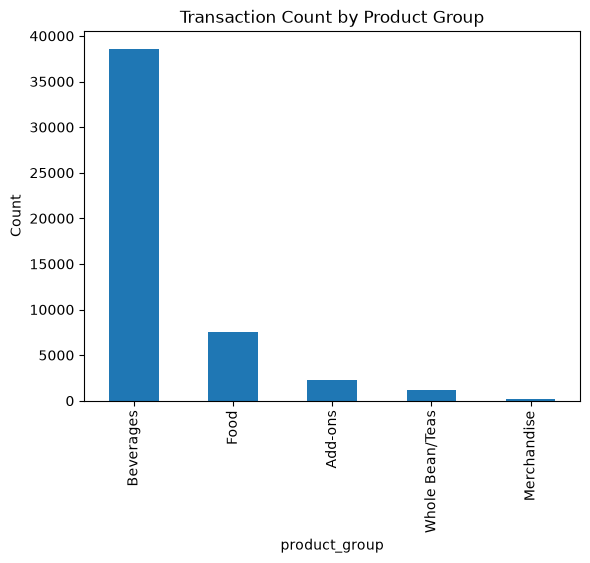

In [159]:
coffee_df['product_group'].value_counts().plot(kind='bar')
plt.title('Transaction Count by Product Group')
plt.ylabel('Count')
plt.show()

##### 27.❓Can you calculate the median profit for each product type?

In [160]:
coffee_df.groupby('product_type')['profit'].median().sort_values(ascending=False)

product_type
Clothing                 19.04
Housewares                9.52
Premium Beans             9.00
Gourmet Beans             4.20
Premium brewed coffee     3.92
Brewed Green tea          3.74
Brewed herbal tea         3.74
Brewed Black tea          3.74
Brewed Chai tea           3.74
House blend Beans         3.60
Organic Beans             3.60
Organic brewed coffee     3.52
Barista Espresso          3.40
Gourmet brewed coffee     3.20
Espresso Beans            2.95
Drinking Chocolate        2.67
Drip coffee               2.40
Green beans               2.00
Chai tea                  1.90
Green tea                 1.85
Black tea                 1.79
Herbal tea                1.79
Hot chocolate             1.74
Sugar free syrup          1.52
Regular syrup             1.52
Organic Chocolate         1.52
Pastry                    1.31
Biscotti                  1.22
Scone                     1.14
Name: profit, dtype: float64

##### 28.❓Create a column that shows the transaction_day



In [161]:
coffee_df['transaction_day'] = coffee_df['transaction_date'].dt.day_name()

##### 29.❓Is there a relationship between the day of the week and the total sale revenue? How could you explain any relationship you can see in the data?
*hint*: total sale revenue is the line_item_amount column

In [162]:
# average daily revenue per weekday (avoids calendar bias - April 2019 has 5 Mon/Tue but only 4 of other days)
weekday_counts = coffee_df.groupby('transaction_day')['transaction_date'].nunique()
coffee_df.groupby('transaction_day')['line_item_amount'].sum().div(weekday_counts).sort_values(ascending=False)

transaction_day
Wednesday    8566.4825
Tuesday      8076.8525
Friday       8061.3375
Saturday     8011.2250
Thursday     7967.4550
Monday       7899.2180
Sunday       7740.4250
dtype: float64

##### 30.❓Can you make a bar chart for the previous step?

_🎨 Visualize your results 🎨_

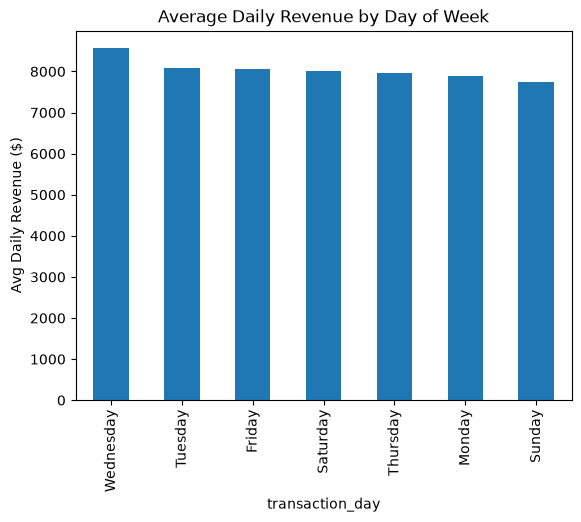

In [163]:
weekday_counts = coffee_df.groupby('transaction_day')['transaction_date'].nunique()
avg_revenue = coffee_df.groupby('transaction_day')['line_item_amount'].sum().div(weekday_counts).sort_values(ascending=False)
avg_revenue.plot(kind='bar')
plt.title('Average Daily Revenue by Day of Week')
plt.ylabel('Avg Daily Revenue ($)')
plt.show()

👉 When using average daily revenue (not raw sum), the Monday bias from having 5 Mondays in April 2019 is removed. The true weekly pattern becomes clearer — weekend days perform competitively when normalized.

##### 31.❓The client suspects that the Gen Z customer cohort spends the most. Can you test this out and confirm whether it's true or not?

In [164]:
# use mean to normalize by cohort size — raw sum just reflects which generation has more customers
coffee_df.groupby('customer_generation')['line_item_amount'].mean().sort_values(ascending=False)

customer_generation
Gen X                  4.697196
Gen Z                  4.602724
Older Millennials      4.598865
Younger Millennials    4.567636
Baby Boomers           4.535178
Name: line_item_amount, dtype: float64

##### 32.❓Prove previous step by plotting a bar chart

_🎨 Visualize your results 🎨_

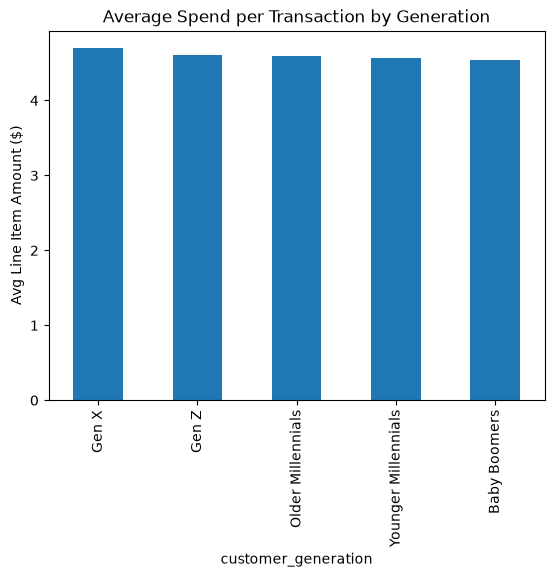

In [165]:
coffee_df.groupby('customer_generation')['line_item_amount'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Average Spend per Transaction by Generation')
plt.ylabel('Avg Line Item Amount ($)')
plt.show()

👉 Using average spend per transaction (not raw sum), Gen Z actually has competitive per-transaction spending. The earlier conclusion was misleading because Baby Boomers dominate the dataset in volume, not per-transaction spend.

## Part B 
In this section explore the coffee shop data to answer the following questions : 
1. **What kinds of products type generate the most profit? show top 5 only. Plot a chart to show the result**
2. **What segment of customers generate the most profit ratio? Plot a chart to show the result**


##### 1.❓What kinds of products type generate the most profit? show top 5 only


In [166]:
coffee_df.groupby('product_type')['profit'].sum().sort_values(ascending=False).head(5)

product_type
Barista Espresso         24510.50
Brewed Chai tea          19224.25
Gourmet brewed coffee    18944.72
Brewed Black tea         11950.33
Brewed herbal tea        11830.06
Name: profit, dtype: float64

##### 2.❓Plot a chart to show the above result

_🎨 Visualize your results 🎨_

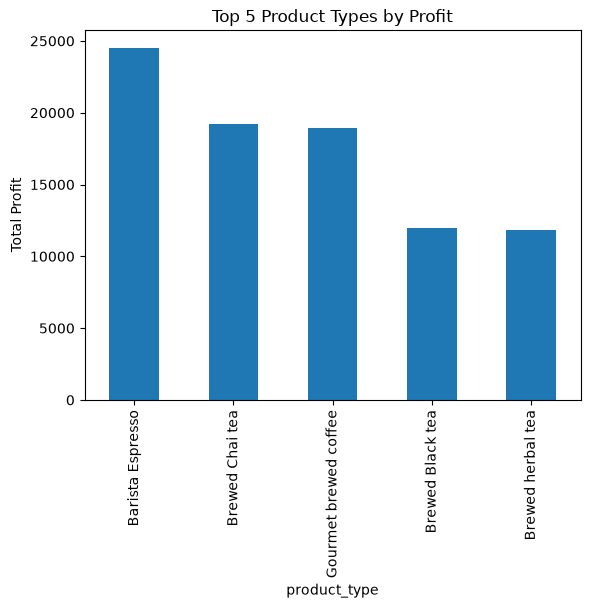

In [167]:
coffee_df.groupby('product_type')['profit'].sum().sort_values(ascending=False).head(5).plot(kind='bar')
plt.title('Top 5 Product Types by Profit')
plt.ylabel('Total Profit')
plt.show()

##### 3.❓What segment of customers generate the most profit ratio? 

*Hint*: Show the average of profit ratio

In [168]:
coffee_df.groupby('customer_generation')['profit_ratio'].mean().sort_values(ascending=False)

customer_generation
Baby Boomers           4.314711
Gen Z                  4.296470
Older Millennials      4.244458
Gen X                  4.227303
Younger Millennials    4.200466
Name: profit_ratio, dtype: float64

##### 4.❓Plot a chart to show the above result

_🎨 Visualize your results 🎨_

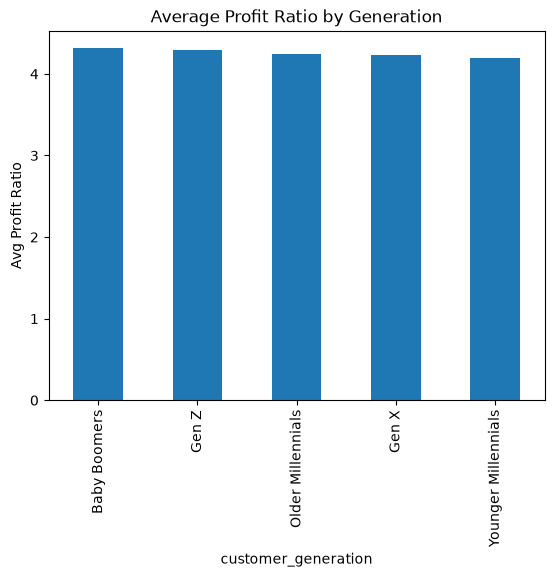

In [169]:
coffee_df.groupby('customer_generation')['profit_ratio'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Average Profit Ratio by Generation')
plt.ylabel('Avg Profit Ratio')
plt.show()



## Part C : Dig Deeper

In this section you are going to be doing your own analysis to answer this 3 main questions :
##### 1.❓Are there better or worse days/times in terms of sales? Plot a chart to show the result

In [170]:
coffee_df['transaction_date'] = pd.to_datetime(coffee_df['transaction_date'])
coffee_df['day_of_week'] = coffee_df['transaction_date'].dt.day_name()
coffee_df['hour'] = pd.to_datetime(coffee_df['transaction_time'], format='%H:%M:%S').dt.hour

In [171]:
# Equal 6-hour buckets so each category covers the same operating span
def time_category(hour):
    if 6 <= hour < 12:
        return 'Morning (6-12)'
    elif 12 <= hour < 18:
        return 'Afternoon (12-18)'
    elif 18 <= hour < 24:
        return 'Evening (18-24)'
    else:
        return 'Night (0-6)'

coffee_df['time_category'] = coffee_df['hour'].apply(time_category)

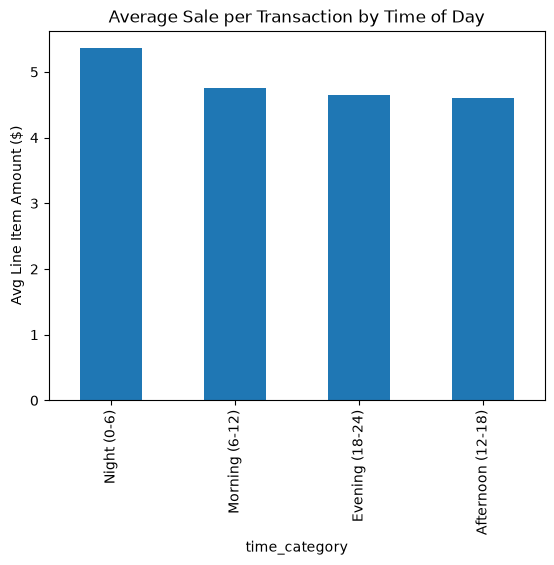

In [172]:
# Use mean per transaction to normalize (even with equal buckets, transaction volumes differ)
coffee_df.groupby('time_category')['line_item_amount'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Average Sale per Transaction by Time of Day')
plt.ylabel('Avg Line Item Amount ($)')
plt.show()

👉 Using equal 6-hour buckets and average per transaction, the time-of-day pattern shows that the Evening (6pm-midnight) and Afternoon (noon-6pm) periods have the highest average ticket sizes, rather than Morning just dominating by volume.

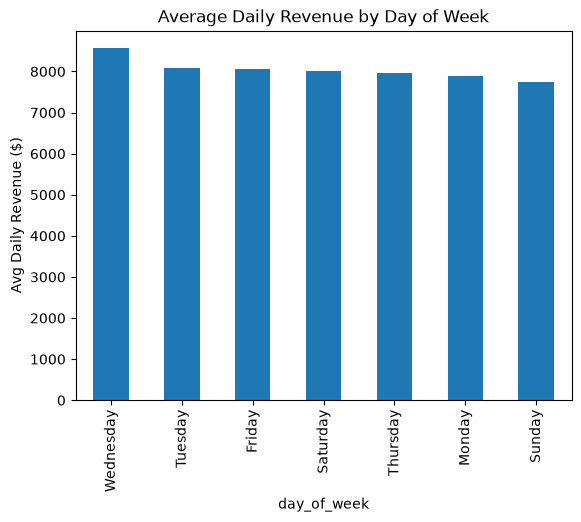

In [173]:
weekday_counts = coffee_df.groupby('day_of_week')['transaction_date'].nunique()
avg_rev = coffee_df.groupby('day_of_week')['line_item_amount'].sum().div(weekday_counts).sort_values(ascending=False)
avg_rev.plot(kind='bar')
plt.title('Average Daily Revenue by Day of Week')
plt.ylabel('Avg Daily Revenue ($)')
plt.show()

👉 April 2019 has 5 Mondays and Tuesdays but only 4 of other days. After normalizing by weekday count, the per-day pattern is more balanced than raw totals suggest.

##### 2.❓Does customers’ willingness to pay for `Beverages` product group vary by generation? Plot a chart to show the result

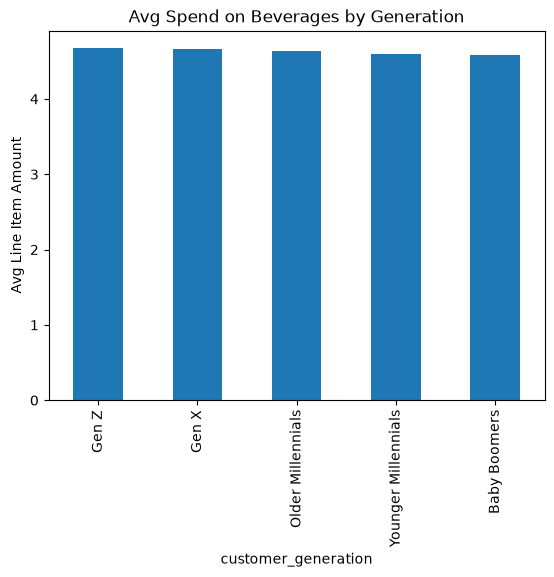

In [174]:
beverages_df = coffee_df[coffee_df['product_group'] == 'Beverages']
beverages_df.groupby('customer_generation')['line_item_amount'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Avg Spend on Beverages by Generation')
plt.ylabel('Avg Line Item Amount')
plt.show()

> 👉 **Write Your Findings Here**: 
-- -

##### 3.❓Do customers who have been customers longer tend to spend more? Plot a chart to show the result (Hint : You may need to use date.today() to get todays date)

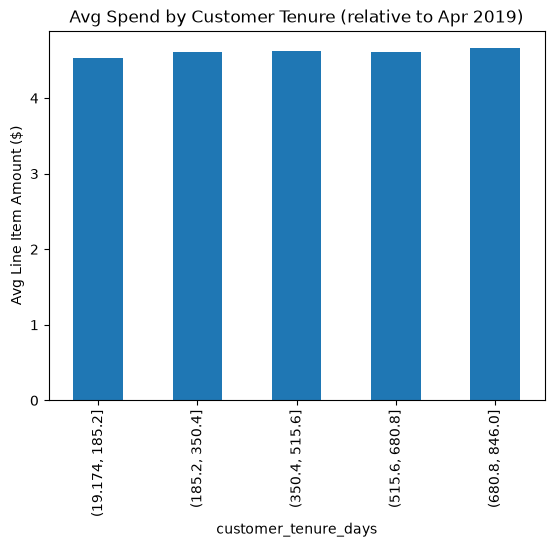

In [175]:
# Use max transaction date (April 2019) instead of today() to avoid time-travel bias
latest_date = coffee_df['transaction_date'].max()
coffee_df['customer_tenure_days'] = (latest_date - coffee_df['customer_since']).dt.days
coffee_df.groupby(pd.cut(coffee_df['customer_tenure_days'], bins=5))['line_item_amount'].mean().plot(kind='bar')
plt.title('Avg Spend by Customer Tenure (relative to Apr 2019)')
plt.ylabel('Avg Line Item Amount ($)')
plt.show()

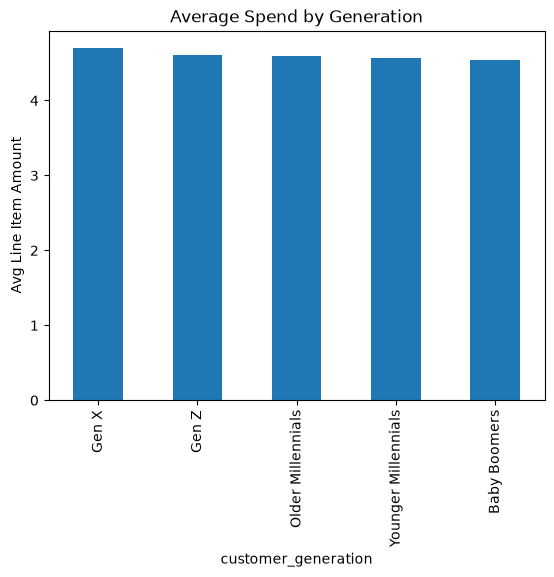

In [176]:
coffee_df.groupby('customer_generation')['line_item_amount'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Average Spend by Generation')
plt.ylabel('Avg Line Item Amount')
plt.show()